In [1]:
pip install openpyxl 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\s159357\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\s159357\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in c:\users\s159357\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local-packages\python311\site-packages (3.10.0)




[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\s159357\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
pip install xlwings 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\s159357\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import openpyxl
import xlwings as xw
import pandas as pd
import shutil
import io
import os
import pandas as pd
import time
import re

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

In [5]:
user_profile = os.getenv('USERPROFILE') ## Retrieving user profile directory from 'USERPROFILE' environment variable.

In [6]:
# Constructing the base directory path using the user profile directory.
base_dir = os.path.join(
    user_profile, 
    'California Department of Transportation',
    'DOT HQ PMP Cal B C Update - General',
    'Testbed'
)

In [7]:
sketch_file_path = os.path.join(base_dir, 'Input', 'cal-bc-8-1-sketch-a11y.xlsm')

In [2]:
def extract_cell_references(formula):
    # Use a regular expression to extract all cell references, both single cells and ranges
    # This pattern captures things like A1, B2, A1:B2, etc.
    pattern = r'[A-Z]+\d+(:[A-Z]+\d+)?'
    references = re.findall(pattern, formula)

    return references


In [1]:
def trace_formula_references(cell, level=0, wb=None):
    # Extract the formula from the cell
    formula = cell.formula
    indent = " " * level  # Create indentation for readability
    
    if not formula:
        # If there's no formula, print the value of the cell instead of the formula
        print(f"{indent}Formula in {cell.address} on sheet {cell.sheet.name}: {cell.value}")
        return
    
    print(f"{indent}Formula in {cell.address} on sheet {cell.sheet.name}: {formula}")
    
    # Extract cell references (individual cells and ranges) from the formula
    references = extract_cell_references(formula)
    
    # For each reference, recursively trace its formula
    for ref in references:
        try:
            # Handle cross-sheet references
            if '!' in ref:
                sheet_name, cell_ref = ref.split('!')
                sheet = wb.sheets[sheet_name]
            else:
                sheet = cell.sheet
                cell_ref = ref

            # If the reference is a range (e.g., W15:AC15)
            if ":" in cell_ref:
                start_cell, end_cell = cell_ref.split(":")
                start_cell = sheet.range(start_cell)
                end_cell = sheet.range(end_cell)
                print(f"{indent}  Range {cell_ref} from {start_cell.address} to {end_cell.address}")
                
                # Loop through all cells in the range (from start_cell to end_cell)
                for row in range(start_cell.row, end_cell.row + 1):
                    for col in range(start_cell.column, end_cell.column + 1):
                        # Get each individual cell in the range and print its value or formula
                        cell_in_range = sheet.range(row, col)
                        
                        # Check if the cell has a formula or is a value
                        if cell_in_range.formula:
                            print(f"{indent}  Formula in {cell_in_range.address} on sheet {cell_in_range.sheet.name}: {cell_in_range.formula}")
                        else:
                            print(f"{indent}  Value in {cell_in_range.address} on sheet {cell_in_range.sheet.name}: {cell_in_range.value}")
                        
                        # Recursively trace this cell's formula if it exists
                        if cell_in_range.formula:
                            trace_formula_references(cell_in_range, level + 2, wb)
            else:
                # If the reference is a single cell (e.g., W15)
                referenced_cell = sheet.range(cell_ref)
                
                # Check if it's a formula or value
                if referenced_cell.formula:
                    print(f"{indent}  Formula in {referenced_cell.address} on sheet {referenced_cell.sheet.name}: {referenced_cell.formula}")
                else:
                    print(f"{indent}  Value in {referenced_cell.address} on sheet {referenced_cell.sheet.name}: {referenced_cell.value}")
                
                # Recursively trace its formula if it exists
                if referenced_cell.formula:
                    trace_formula_references(referenced_cell, level + 2, wb)
        except Exception as e:
            print(f"{indent}  Could not trace {ref}: {str(e)}")


In [8]:
app = xw.App(visible=False)
wb = app.books.open(sketch_file_path)

com_error: (-2147352567, 'Exception occurred.', (0, 'Microsoft Excel', "Microsoft Excel cannot access the file 'C:\\Users\\s159357\\California Department of Transportation\\DOT HQ PMP Cal B C Update - General\\Testbed\\Input\\cal-bc-8-1-sketch-a11y.xlsm'. There are several possible reasons:\n\n• The file name or path does not exist.\n• The file is being used by another program.\n• The workbook you are trying to save has the same name as a currently open workbook.", 'xlmain11.chm', 0, -2146827284), None)

In [2]:
ws = wb.sheets[2]
cell = ws.range('AD15')

NameError: name 'wb' is not defined

In [ ]:
trace_formula_references(cell, wb=wb)

Formula in $AD$15 on sheet 1) Project Information: =SUM(W15:AC15)*1000
  Range W15:AC15 from $W$15 to $AC$15
  Formula in $W$15 on sheet 1) Project Information: 775
  Formula in $X$15 on sheet 1) Project Information: 1475
  Formula in $Y$15 on sheet 1) Project Information: 5000


In [ ]:
def build_formula_tree(formula_data):

    graph = nx.DiGraph()  

    # Add each cell as a node
    for cell, formula in formula_data.items():
        graph.add_node(cell, formula=formula)

    # Add edges based on cell references in the formula
    for cell, formula in formula_data.items():
        references = extract_cell_references(formula)
        for ref in references:
            graph.add_edge(cell, ref)  # Add directed edge from current cell to the referenced cell

    return graph

In [ ]:
formula_data = {
    "$AD$15": "=SUM(W15:AC15)*1000",
    "$W$15": "775",
    "$X$15": "1475",
    "$Y$15": "5000",
}


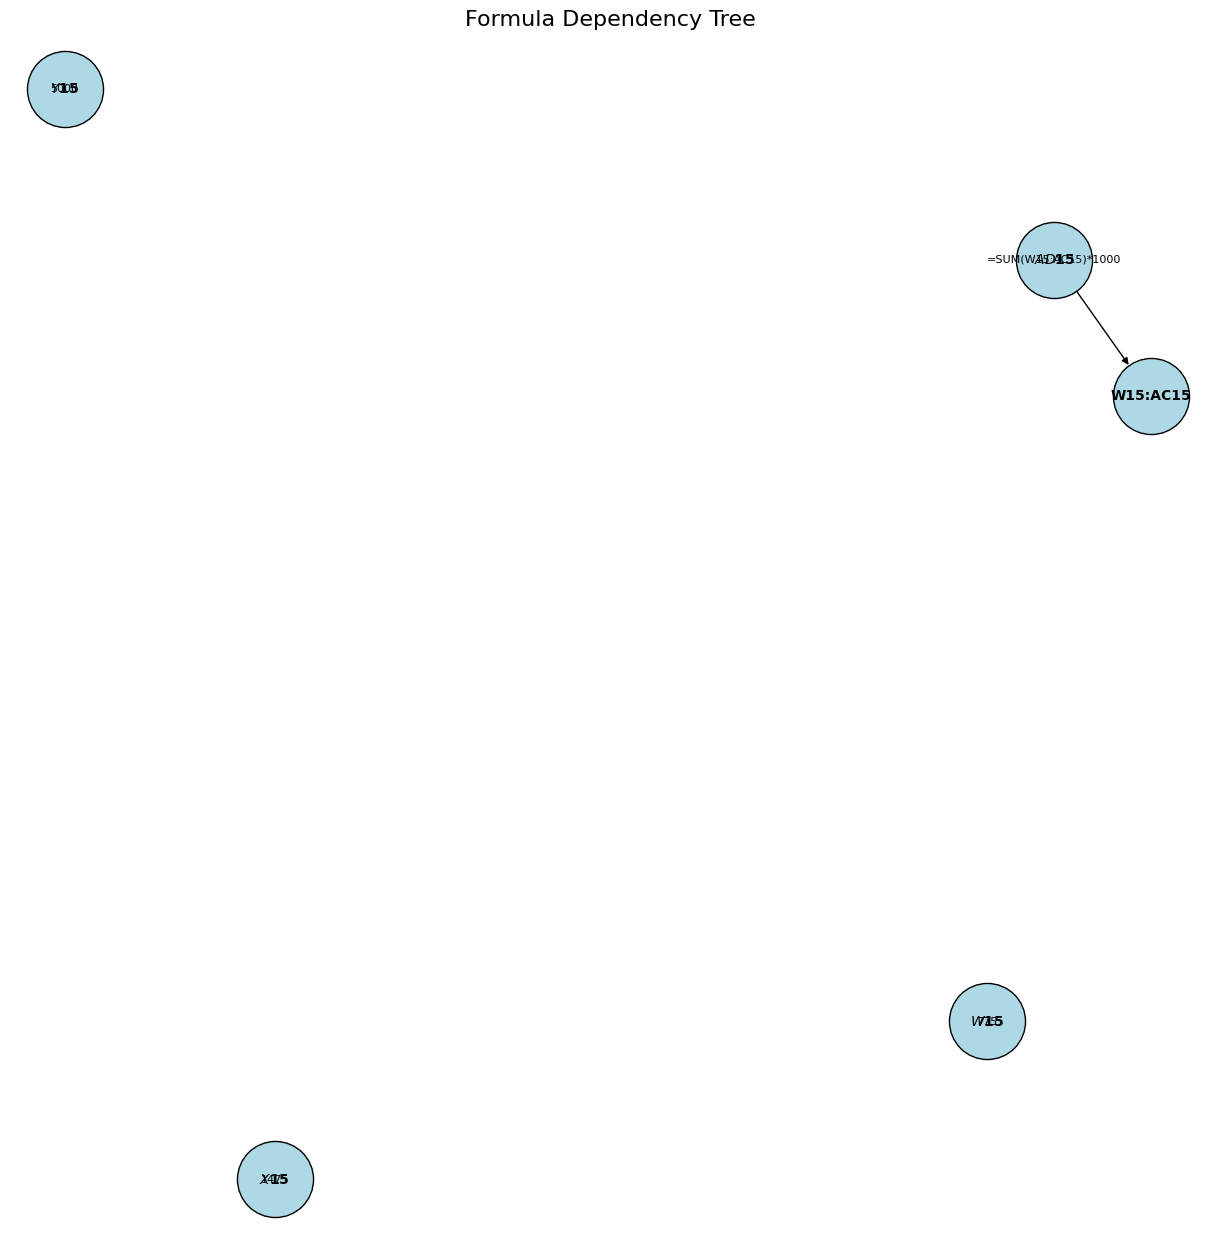

In [ ]:
graph = build_formula_tree(formula_data)
draw_formula_tree(graph)